In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np 

In [3]:
df=pd.read_csv("adult_preprocessed.csv")
print(df.head())

   age  education.num  capital.gain  capital.loss  ...  race_Black race_Other  race_White  sex_Male
0   90              9             0          4356  ...       False      False        True     False
1   82              9             0          4356  ...       False      False        True     False
2   66             10             0          4356  ...        True      False       False     False
3   54              4             0          3900  ...       False      False        True     False
4   41             10             0          3900  ...       False      False        True     False

[5 rows x 44 columns]


In [4]:
X =df.drop(columns=["income"])
y = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

In [5]:
from sklearn.model_selection import train_test_split
X_train , X_test, y_train, y_test = train_test_split(X , y , test_size= 0.30, random_state= 42)

In [6]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()

In [7]:
dtc.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [8]:
dtc.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [9]:
y_pred = dtc.predict(X_test)

In [10]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[6604  825]
 [ 933 1407]]


In [11]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.89      0.88      7429
           1       0.63      0.60      0.62      2340

    accuracy                           0.82      9769
   macro avg       0.75      0.75      0.75      9769
weighted avg       0.82      0.82      0.82      9769



In [12]:
features = pd.DataFrame(
    {
        'Feature': X.columns,
        'Importance': dtc.feature_importances_
    }
)

features = features.sort_values('Importance', ascending=False)
print(features)

                                 Feature  Importance
14     marital.status_Married-civ-spouse    0.215661
0                                    age    0.170354
1                          education.num    0.146329
2                           capital.gain    0.115500
4                         hours.per.week    0.098619
3                           capital.loss    0.045127
8                      workclass_Private    0.017173
21            occupation_Exec-managerial    0.014972
10            workclass_Self-emp-not-inc    0.012494
20               occupation_Craft-repair    0.012204
41                            race_White    0.011845
30                      occupation_Sales    0.011772
42                              sex_Male    0.011566
28             occupation_Prof-specialty    0.010861
5                    workclass_Local-gov    0.010019
39                            race_Black    0.007557
9                 workclass_Self-emp-inc    0.007315
37                     relationship_Wife    0.

In [13]:
dtc2 = DecisionTreeClassifier(criterion='entropy',ccp_alpha=0.04)

In [14]:
dtc2.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"ccp_alpha ccp_alpha: non-negative float, default=0.0Complexity parameter used for Minimal Cost-Complexity Pruning. Thesubtree with the largest cost complexity that is smaller than``ccp_alpha`` will be chosen. By default, no pruning is performed. See:ref:`minimal_cost_complexity_pruning` for details. See:ref:`sphx_glr_auto_examples_tree_plot_cost_complexity_pruning.py`for an example of such pruning... versionadded:: 0.22",0.04
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.

In [15]:
y_pred2 = dtc2.predict(X_test)

In [16]:
cm = confusion_matrix(y_test, y_pred2)
print(cm)

[[7057  372]
 [1411  929]]


In [17]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.83      0.95      0.89      7429
           1       0.71      0.40      0.51      2340

    accuracy                           0.82      9769
   macro avg       0.77      0.67      0.70      9769
weighted avg       0.80      0.82      0.80      9769



In [18]:
from sklearn.tree import plot_tree

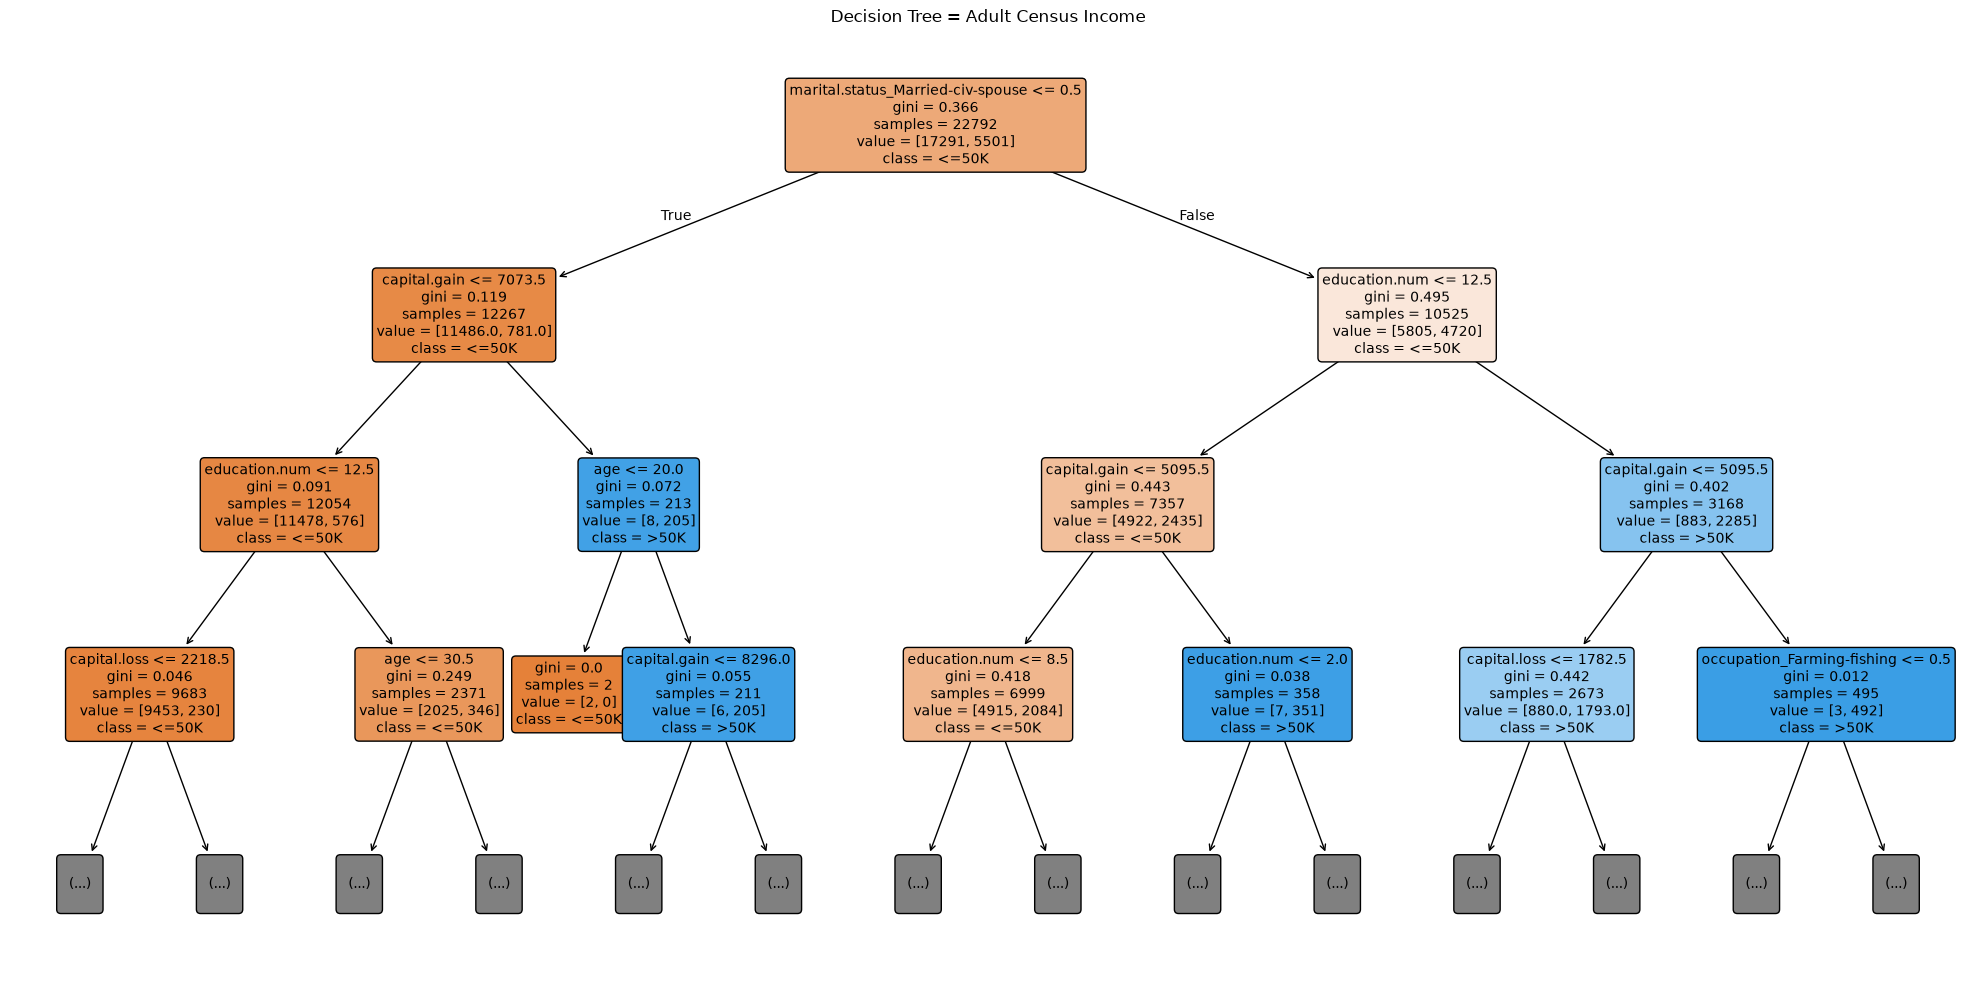

In [23]:
plt.figure(figsize=(20,10))
plot_tree(
    dtc,
    feature_names=X.columns.to_list(), 
    class_names=["<=50K", ">50K"],
    filled = True,
    rounded= True,
    fontsize= 10, 
    max_depth = 3
)

plt.title("Decision Tree = Adult Census Income")
plt.tight_layout()
plt.show()

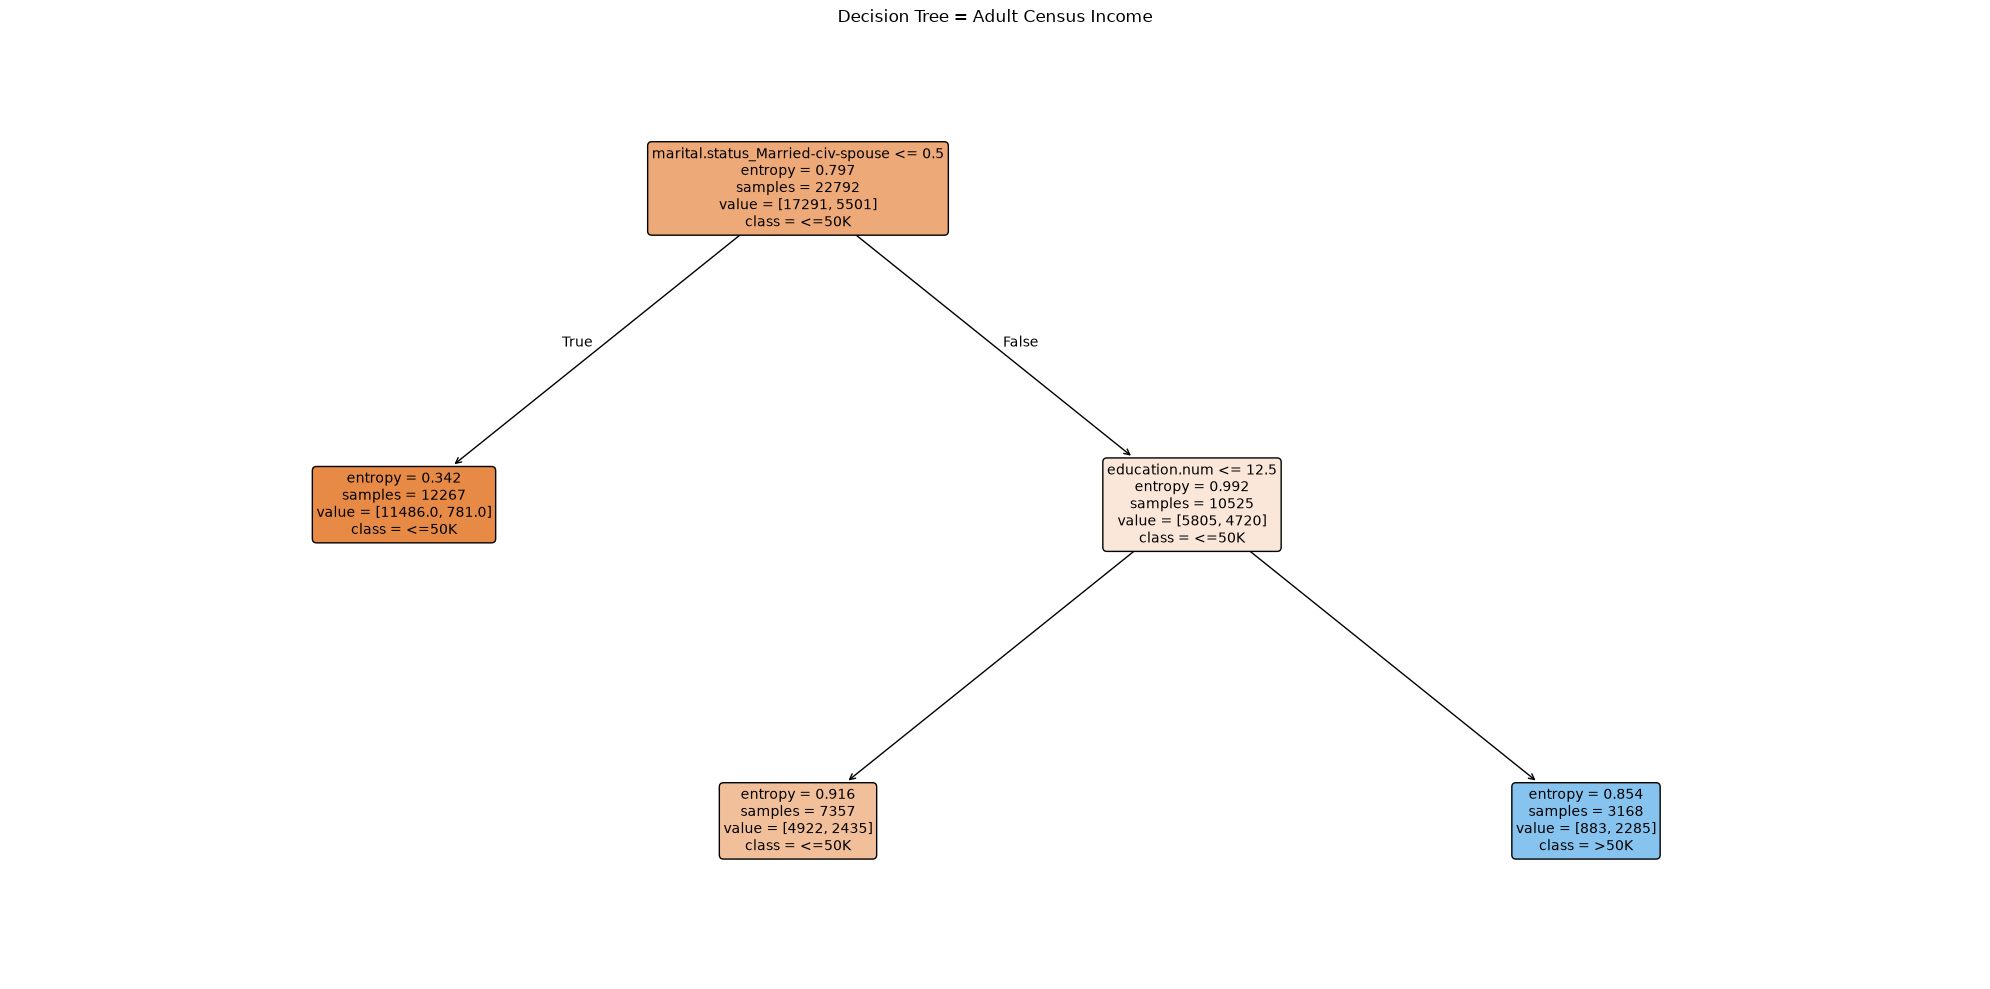

In [24]:
plt.figure(figsize=(20,10))
plot_tree(
    dtc2,
    feature_names=X.columns.to_list(), 
    class_names=["<=50K", ">50K"],
    filled = True,
    rounded= True,
    fontsize= 10, 
    max_depth = 3
)

plt.title("Decision Tree = Adult Census Income")
plt.tight_layout()
plt.show()

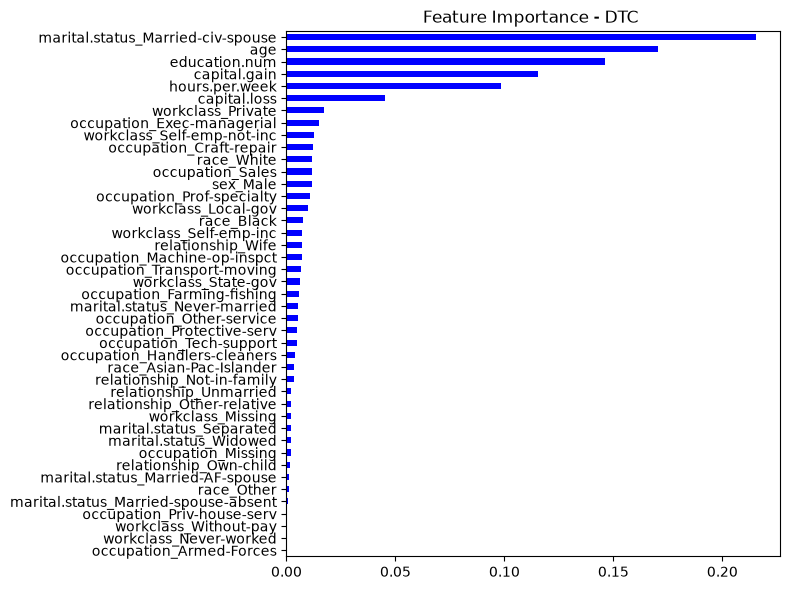

In [27]:
importances = pd.Series(
    dtc.feature_importances_,
    index = X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize = (8,6))
importances.plot(kind="barh", ax = ax , color="blue")
ax.set_title("Feature Importance - DTC ")
ax.axvline(x =0, color="black", linewidth = 0.5)
plt.tight_layout()
plt.show()

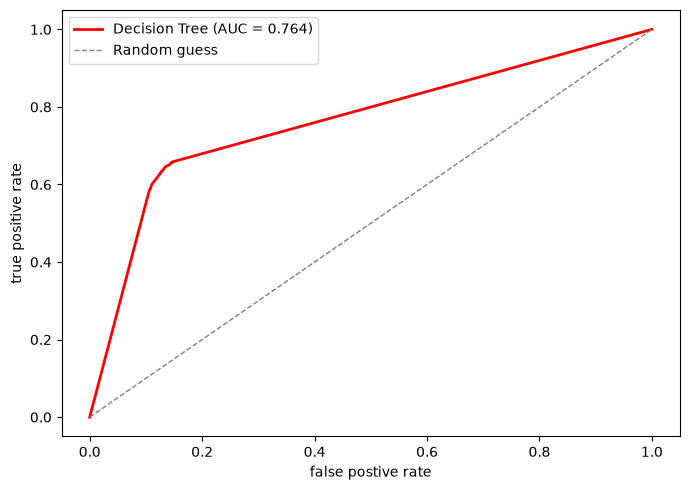

In [31]:
from sklearn.metrics import roc_curve , roc_auc_score

y_prob = dtc.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test , y_prob)
auc = roc_auc_score(y_test,y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color="red", lw=2,
        label=f"Decision Tree (AUC = {auc:.3f})")
plt.plot([0,1],[0,1], color="gray", lw=1, linestyle="--",
         label="Random guess")
plt.xlabel("false postive rate")
plt.ylabel("true positive rate")
plt.legend()
plt.tight_layout()
plt.show()

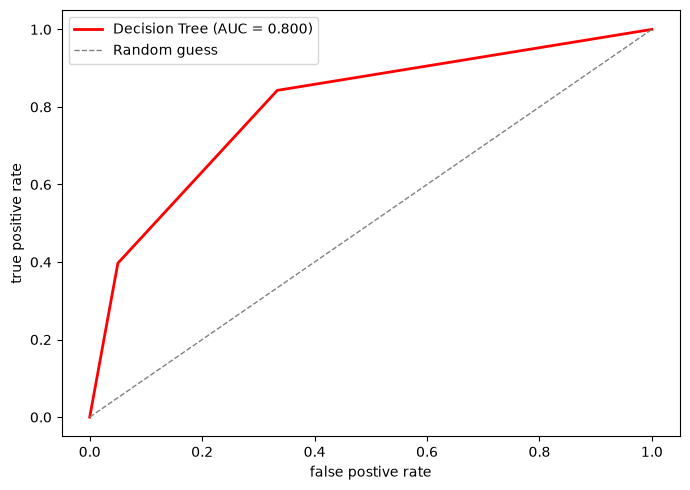

In [32]:
y_prob = dtc2.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test , y_prob)
auc = roc_auc_score(y_test,y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color="red", lw=2,
        label=f"Decision Tree (AUC = {auc:.3f})")
plt.plot([0,1],[0,1], color="gray", lw=1, linestyle="--",
         label="Random guess")
plt.xlabel("false postive rate")
plt.ylabel("true positive rate")
plt.legend()
plt.tight_layout()
plt.show()

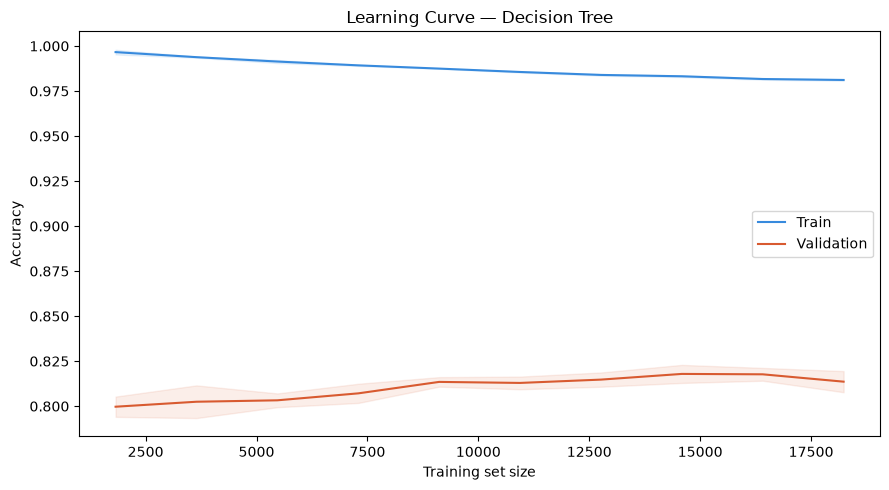

In [33]:
from sklearn.model_selection import learning_curve

sizes, train_s, test_s = learning_curve(
    dtc, X_train, y_train,
    cv=5, train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)

plt.figure(figsize=(9, 5))
plt.plot(sizes, train_s.mean(1), label="Train", color="#378ADD")
plt.plot(sizes, test_s.mean(1), label="Validation", color="#D85A30")
plt.fill_between(sizes, train_s.mean(1)-train_s.std(1),
                 train_s.mean(1)+train_s.std(1), alpha=0.1, color="#378ADD")
plt.fill_between(sizes, test_s.mean(1)-test_s.std(1),
                 test_s.mean(1)+test_s.std(1), alpha=0.1, color="#D85A30")
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve — Decision Tree")
plt.legend()
plt.tight_layout()
plt.show()